In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

In [3]:
df=pd.read_csv("thyroidDB.csv",sep=";")
df.head()
df.describe
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(";;", "")
print(df.columns)

Index(['Age', 'Sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3_measured',
       'TT4_measured', 'T4U_measured', 'FTI_measured', 'Outlier_label',
       'Unnamed: 22', 'Unnamed: 23'],
      dtype='object')


In [22]:
x=df.drop("Outlier_label",axis=1)
y=df["Outlier_label"]

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

x_imputed = imputer.fit_transform(x)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x_imputed)
x_scaled

C:\Users\91965\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Unnamed: 22' 'Unnamed: 23']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


array([[-2.34449113e-02,  1.50050924e+00, -3.94405319e-01, ...,
        -1.40951598e+00, -3.74590514e-02, -1.25859776e+00],
       [ 2.40791602e-03, -6.66440415e-01, -3.94405319e-01, ...,
        -6.57814578e-01,  2.27969782e-01, -5.68029663e-01],
       [-7.03031607e-02, -6.66440415e-01,  2.53546276e+00, ...,
        -7.17159426e-01,  4.34414431e-01, -7.13412420e-01],
       ...,
       [-2.99081181e-02, -6.66440415e-01, -3.94405319e-01, ...,
         6.08208844e-01,  7.58827450e-01,  2.49748343e-01],
       [ 7.25532113e-03,  1.50050924e+00, -3.94405319e-01, ...,
         2.32358141e-01, -7.96695877e-03,  4.67822478e-01],
       [-2.18291096e-02, -6.66440415e-01, -3.94405319e-01, ...,
        -2.48028670e-02,  8.05093192e-02,  1.22538431e-01]],
      shape=(6916, 21))

In [23]:
from sklearn.ensemble import IsolationForest
clf=IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42
)
labels=clf.fit_predict(x_scaled)


In [24]:
labels
np.isnan(x_scaled).sum()

np.int64(0)

In [25]:
#visualize
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

Text(0, 0.5, 'PC2')

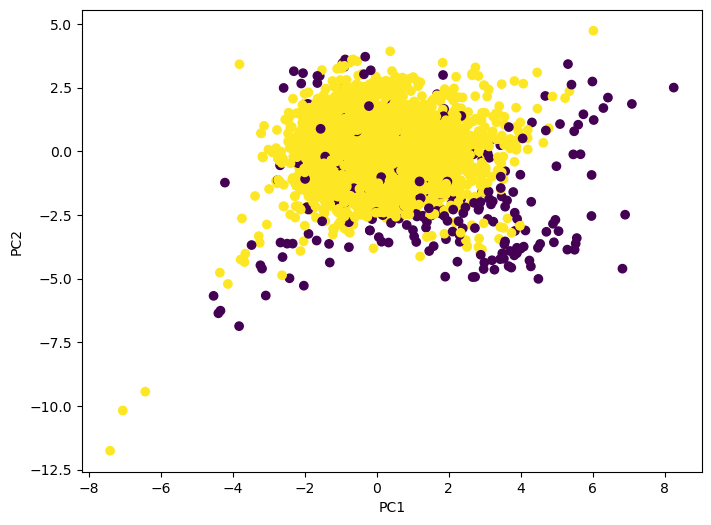

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [30]:
n_outlier=np.sum(labels ==-1)
n_normal=np.sum(labels==1)
print("outlier =",n_outlier)
print("normal=",n_normal)

outlier = 270
normal= 6646


In [33]:
#LOF
from sklearn.neighbors import LocalOutlierFactor
neighbs=LocalOutlierFactor(contamination=0.03)
labels=neighbs.fit_predict(x_scaled)

Text(0, 0.5, 'PC2')

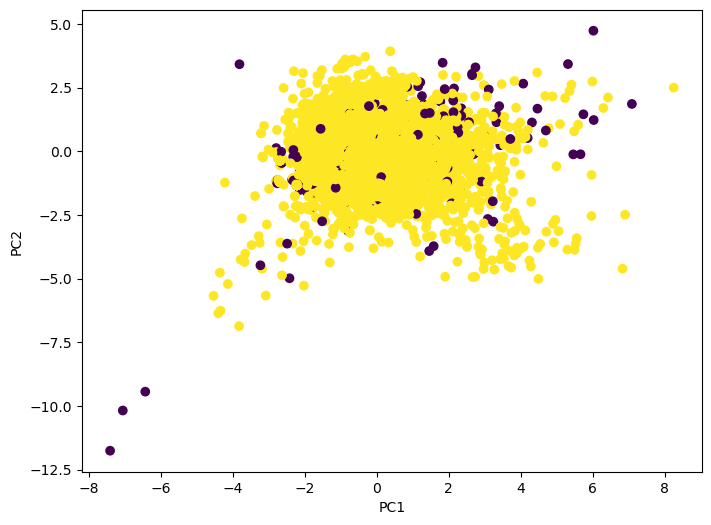

In [34]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [35]:
n_outlier=np.sum(labels ==-1)
n_normal=np.sum(labels==1)
print("outlier =",n_outlier)
print("normal=",n_normal)

outlier = 208
normal= 6708
